# Credit Risk EDA

## Library imports 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Overview
* Dataset contains total 1000 rows, 10 columns
* Unnamed column to remove (redundant)
* Age column - No null values, Can be categorized into multiple groups. Insights can be found which age group took loan for which pupose and etc.,
* Sex - No null values, contains two categories, no null values
    - Male - 690 instances
    - Female - 310 instances
* Job - contains values [0 1 2 3], no null values - replace these numbers with their actual category labels
    - 0 (Unskilled and non-resident) - 22  instances
    - 1 (Unskilled and resident) - 200 instances
    - 2 (Skilled) - 630 instances
    - 3 (Highly skilled) - 148 instances
* Housing - Tells whether house is ['own', 'rent', 'free'], no null values
    - own - 713
    - rent - 179
    - free - 108
* Missing values in both columns will be imputed using mode, as dropping would remove 18–39% of data for following columns
    - Savings accounts -> Has the following values little, moderate, rich, quite rich and with null values of 183
        - little      -  603
        - moderate    -  103
        - quite rich  -   63
        - rich        -   48
    - Checking accounts -> Has the following values little, moderate, rich and with null values of 394
        - little    -  274
        - moderate  -  269
        - rich      -   63
* Credit amount - No null values
* Purpose contains following values with no null values
    - domestic appliances  -   12
    - vacation/others      -   12
    - repairs              -   22
    - education            -   59
    - business             -   97
    - furniture/equipment  -  181
    - radio/TV             -  280
    - car                  -  337

* Risk - contains good / bad (no null values)
    good  -  700
    bad   -  300
* Risk is imbalanced 70/30 — model will need to handle this

In [11]:
df = pd.read_csv('../data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [12]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [14]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [15]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


## Visualization

### Histogram Age vs Risk

* Initial Analysis (Before Plotting)
    - Young People aged between 25 - 35 will mostly default the loan.
    - There might be other factors too if they loose job their source of income might not be there they can default, sometimes due to money constraints they might have paid only minimum dues, old people who are dead might default (ofc their insurance will cover)
* After Plotting
    - Turns out we can see more defaulters in the age group of 23 -29
    - Defaulters rate gradually decreasing but still good amount of defaulters present upto age 38
    - And very few defaulters as age increases, it might be because as age grows stable job, pension, saving also can increase so there is less defaulters as age grows


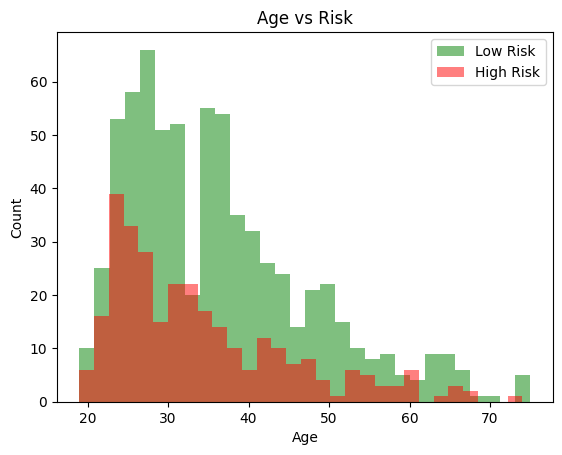

In [16]:
fig, ax = plt.subplots()
ax.hist(df[df['Risk'] == 'good']['Age'], alpha=0.5, bins=30, label='Low Risk', color='g')
ax.hist(df[df['Risk'] == 'bad']['Age'], alpha=0.5, bins=30, label='High Risk', color='r')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age vs Risk')
plt.legend()
plt.show()

### Credit amount distribution split by Risk

* Analysis Before Plotting
    - High amount - Hight chances for defaulting as emi is more
    - Low amount - Low EMI less chances of defaulting 
* Analysis After Plotting
    - Turns out for less amount there are more defaulters
    - people taking small loans are often lower income or financially stressed already, whereas people taking large loans may have better credit profiles and assets to back them up.

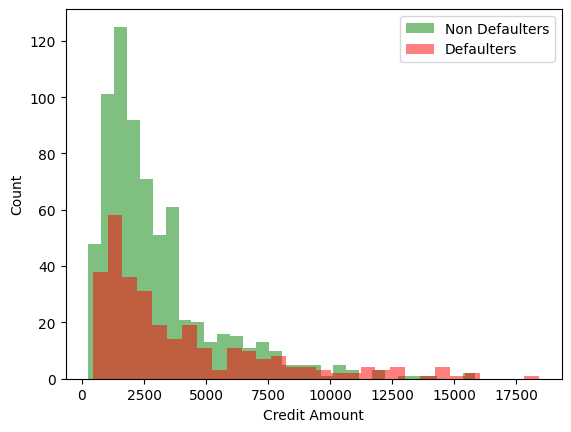

In [17]:
fig, ax = plt.subplots()
ax.hist(df[df['Risk'] == 'good']['Credit amount'], alpha=0.5, bins=30, label='Non Defaulters', color='green')
ax.hist(df[df['Risk'] == 'bad']['Credit amount'], alpha=0.5, bins=30, label='Defaulters', color='red')
ax.set_xlabel('Credit Amount')
ax.set_ylabel('Count')
plt.legend()
plt.show()

### Risk count by Purpose

* Before Prediction
    - domestic appliances  -   Less default rate
    - vacation/others      -   More default rate
    - repairs              -   More default rate
    - education            -   More default rate (until people get decent job)
    - business             -   More default rate (Most of the businesses fail)
    - furniture/equipment  -   Less default rate
    - radio/TV             -   Less default rate
    - car                  -   Less default rate
- Things purchased can be paid off by selling them, by which they can payoff if income goes side ways, but which are non recoverable they might default the loan


* After Prediction
    - Vacation/others — 42% — highest defaulter 
    - Repairs — 38%
    - Education — 39% — high, as you predicted
    - Business — 35% — you predicted high, data agrees
    - Radio/TV — 24% — lowest defaulter
    - Car — 33% — you predicted low, data agrees


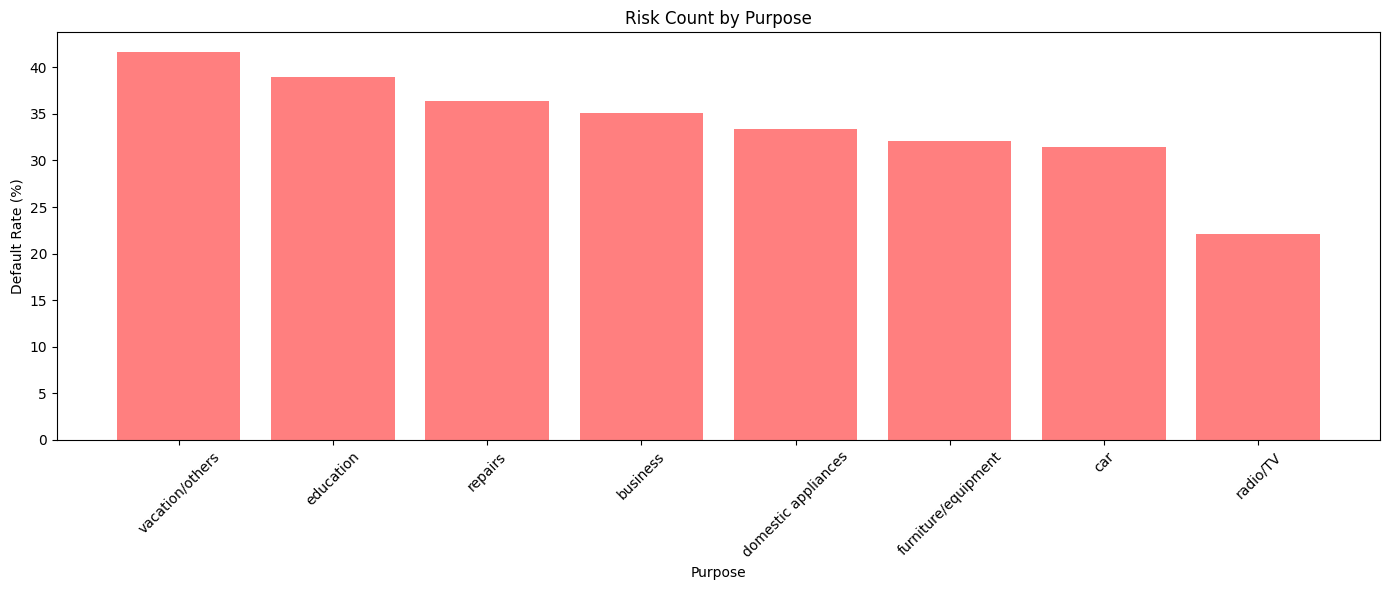

In [18]:
default_rate = df.groupby('Purpose')['Risk'].apply(
    lambda x: (x == 'bad').mean() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(default_rate.index, default_rate.values, alpha=0.5, color='red')
ax.set_xlabel('Purpose')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Risk Count by Purpose')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Defaulters (bad risk) tend to take higher credit amounts 
across all housing types. Housing type alone is not a strong 
differentiator — loan amount matters more than where someone lives.

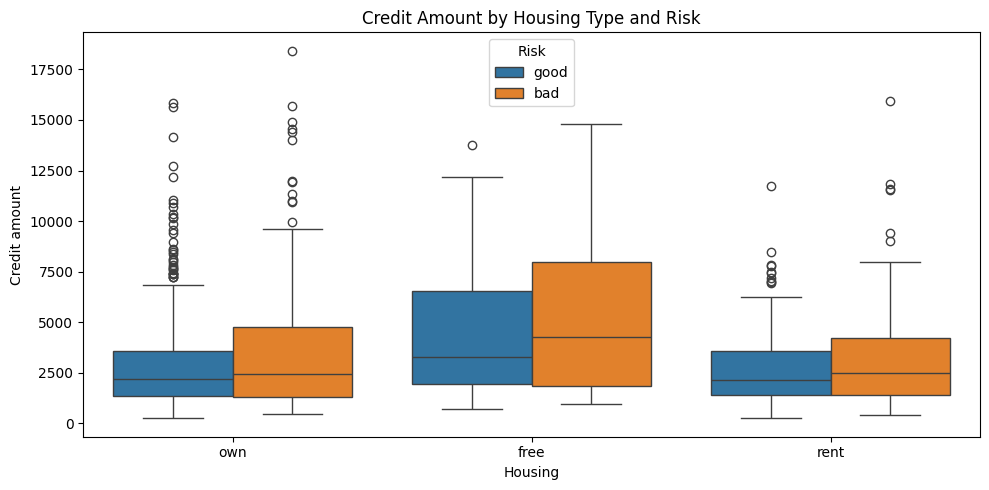

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Housing', y='Credit amount', hue='Risk')
plt.title('Credit Amount by Housing Type and Risk')
plt.tight_layout()
plt.savefig('../figures/credit_amount_by_housing.png')
plt.show()